In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import random

import cebra
import cebra.datasets
from cebra import CEBRA
# import cebra.sklearn.metrics
import cebra.integrations.plotly

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy.ma as ma

USE_ENSEMBLES = False

# ── Load data ──────────────────────────────────────────────────────────────
base = "./outputs/glm_input_data/"

results_base = "./outputs/lstm/"

beh_vals = np.load(os.path.join(base, "behavior_glm_input.npy"), allow_pickle=True)
beh_idx  = np.load(os.path.join(base, "behavior_glm_input_index.npy"), allow_pickle=True)
beh_cols = np.load(os.path.join(base, "behavior_glm_input_columns.npy"), allow_pickle=True)

spk_vals = np.load(os.path.join(base, "fr_full.npy"))
spk_idx  = np.load(os.path.join(base, "fr_full_index.npy"), allow_pickle=True)
spk_cols = np.load(os.path.join(base, "fr_full_columns.npy"), allow_pickle=True)

ensembles_file   = os.path.join(base, "ensembles.npy")
ensembles_values = np.load(ensembles_file)

try:
    beh_index = pd.MultiIndex.from_tuples(beh_idx, names=behavior_glm_input.index.names)
except Exception:
    beh_index = pd.Index(beh_idx)

try:
    spk_index = pd.MultiIndex.from_tuples(spk_idx, names=fr_first7.index.names)
except Exception:
    spk_index = pd.Index(spk_idx)

behavior_glm_loaded = pd.DataFrame(beh_vals, index=beh_index, columns=beh_cols)
spikes_loaded       = pd.DataFrame(spk_vals, index=spk_index, columns=spk_cols)

print("behavior_glm_loaded shape", behavior_glm_loaded.shape)
print("spikes_loaded shape",       spikes_loaded.shape)

behavior_glm_loaded shape (1333016, 29)
spikes_loaded shape (1333016, 77)


In [2]:
# ── Preprocessing (identical to train_linear) ───────────────────────────────
spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)

spikes_unique_trials = set(idx[0] for idx in spikes_loaded.index)
behavior_glm_loaded  = behavior_glm_loaded[
    behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)
]

non_nan_rows        = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded       = spikes_loaded.loc[non_nan_rows]

behavior_glm_loaded = behavior_glm_loaded.drop("track_zone", axis=1)

session_ids = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
print(f"{len(session_ids)} sessions")

29 sessions


In [3]:
# ── Feature columns ─────────────────────────────────────────────────────────
action_enc_cols = [
    'frame_raw_500msMedian',
    'frame_YawPitch_abs_vel_sum_500msMedian',
    'upcoming_choice',
    'reward_window',
    'frame_raw_abs_acc_500msMedian',
    'frame_YawPitch_abs_acc_sum_500msMedian',
    'forward_vs_rotation_corr',
    'head_angle',
    'head_angle_vel',
    'movement_energy_smooth5',
    'lick_detected',
]

In [4]:
# ── Build session dataset (identical to train_linear) ───────────────────────
session_dataset_singles = {}

for session_id in session_ids:
    session_mask   = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
    beh            = behavior_glm_loaded[session_mask]
    spikes_session = spikes_loaded[session_mask]

    for col in action_enc_cols:
        if col in beh.columns:
            beh.loc[:, col] = beh[col].astype(float)
            mean_val = beh[col].mean()
            std_val  = beh[col].std() + 1e-8
            if std_val != 0:
                beh.loc[:, col] = (beh[col] - mean_val) / std_val

    spikes_session = spikes_session.astype(float)
    if USE_ENSEMBLES:
        spikes_values      = spikes_session.values
        new_spikes_session = pd.DataFrame(index=spikes_session.index)
        for i in range(ensembles_values.shape[1]):
            ensemble = ensembles_values[:, i]
            new_spikes_session[f'ensemble_{i}'] = spikes_values @ ensemble
        spikes_session = new_spikes_session

    label_stds = []
    for col in spikes_session.columns:
        mean_val = spikes_session[col].mean()
        std_val  = spikes_session[col].std() + 1e-8
        label_stds.append(std_val)
        if std_val != 0:
            spikes_session[col] = (spikes_session[col] - mean_val) / std_val

    data_by_trial, labels_by_trial = {}, {}
    for trial_id in beh["trial_id"].unique():
        trial_mask              = beh["trial_id"] == trial_id
        data_by_trial[trial_id]   = beh.loc[trial_mask, action_enc_cols].values.astype(np.float32)
        labels_by_trial[trial_id] = spikes_session.loc[trial_mask].values.astype(np.float32)

    session_dataset_singles[session_id] = {
        "data":       data_by_trial,
        "labels":     labels_by_trial,
        "label_stds": label_stds,
    }

print("Dataset built.")

Dataset built.


In [5]:
# ── Train/test split (reuse saved indices if available) ─────────────────────
split_path = "test_indices_by_session.npy"

if os.path.exists(split_path):
    test_indices_by_session = np.load(split_path, allow_pickle=True).item()
    print(f"Loaded existing split from {split_path}")
else:
    test_indices_by_session = {}
    train_test_split = 0.8
    for session in session_ids:
        indices = list(session_dataset_singles[session]["data"].keys())
        np.random.shuffle(indices)
        split_idx = int(len(indices) * train_test_split)
        test_indices_by_session[session] = indices[split_idx:]
    np.save(split_path, test_indices_by_session, allow_pickle=True)
    print(f"Saved new split to {split_path}")

Loaded existing split from test_indices_by_session.npy


In [6]:
# ── Config ───────────────────────────────────────────────────────────────────
models_dir = "./models/cebra/ensembles" if USE_ENSEMBLES else "./models/cebra/spikes"
output_dir = "./outputs/cebra/ensembles" if USE_ENSEMBLES else "./outputs/cebra/spikes"
os.makedirs(models_dir, exist_ok=True)
os.makedirs(output_dir,  exist_ok=True)

input_size   = len(action_enc_cols)
num_sessions = len(session_ids)
num_neurons  = ensembles_values.shape[1] if USE_ENSEMBLES else spikes_loaded.shape[1]

# CEBRA shared hyperparameters
CEBRA_KWARGS = dict(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.12,
    output_dimension=64,
    distance="cosine",
    max_iterations=5000,
    device="cuda_if_available",
    verbose=False,
    time_offsets=10,
)

print(f"input_size={input_size}, num_sessions={num_sessions}, num_neurons={num_neurons}")

input_size=11, num_sessions=29, num_neurons=77


## Time-contrastive CEBRA (unsupervised)

One model per session. Train on 80% of trials (by trial_id), evaluate GoF on held-out 20%.

In [7]:
# ── LOOP 1: Train time-contrastive CEBRA per session ────────────────────────
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

gof_time_train = np.zeros(num_sessions)
gof_time_test  = np.zeros(num_sessions)

for sess_idx, session_id in enumerate(session_ids):
    session_data   = session_dataset_singles[session_id]["data"]
    session_labels = session_dataset_singles[session_id]["labels"]

    test_trial_ids  = [int(idx) for idx in test_indices_by_session[session_id]]
    all_trial_ids   = list(session_data.keys())
    train_trial_ids = [idx for idx in all_trial_ids if idx not in test_trial_ids]

    train_data = np.concatenate([session_data[idx]   for idx in train_trial_ids], axis=0)
    test_data  = np.concatenate([session_data[idx]   for idx in test_trial_ids],  axis=0)

    print(f"[{sess_idx+1}/{num_sessions}] {session_id}  "
          f"train={train_data.shape[0]}  test={test_data.shape[0]}")

    model = CEBRA(conditional="time", **CEBRA_KWARGS)
    model.fit(train_data)

    gof_train = cebra.sklearn.metrics.goodness_of_fit_score(model, train_data)
    gof_test  = cebra.sklearn.metrics.goodness_of_fit_score(model, test_data)

    gof_time_train[sess_idx] = gof_train
    gof_time_test[sess_idx]  = gof_test

    model_path = os.path.join(models_dir, f"time_session_{sess_idx:02d}.pt")
    model.save(model_path)

    print(f"  GoF train={gof_train:.4f}  GoF test={gof_test:.4f}  → saved")

np.save(os.path.join(output_dir, "gof_time_train.npy"), gof_time_train)
np.save(os.path.join(output_dir, "gof_time_test.npy"),  gof_time_test)
print("\nTime-contrastive training complete.")

[1/29] 2024-11-14_16-40  train=17835  test=5075
  GoF train=0.9688  GoF test=0.9211  → saved
[2/29] 2024-11-15_15-48  train=33498  test=8349
  GoF train=0.9964  GoF test=0.9720  → saved
[3/29] 2024-11-20_17-46  train=21332  test=4615
  GoF train=1.0048  GoF test=0.9208  → saved
[4/29] 2024-11-21_17-22  train=24156  test=5604
  GoF train=1.0214  GoF test=0.9843  → saved
[5/29] 2024-11-25_16-25  train=15395  test=4009
  GoF train=1.0325  GoF test=0.9724  → saved
[6/29] 2024-11-26_16-39  train=23576  test=5659
  GoF train=1.0041  GoF test=0.9707  → saved
[7/29] 2024-11-28_17-41  train=27785  test=6933
  GoF train=0.9687  GoF test=0.9039  → saved
[8/29] 2024-11-29_17-21  train=1950  test=619
  GoF train=1.1092  GoF test=0.4081  → saved
[9/29] 2024-12-02_16-09  train=25384  test=5367
  GoF train=0.9770  GoF test=0.9205  → saved
[10/29] 2024-12-03_16-23  train=27330  test=6229
  GoF train=0.9956  GoF test=0.9220  → saved
[11/29] 2024-12-04_18-06  train=25270  test=5404
  GoF train=0.9864  Go

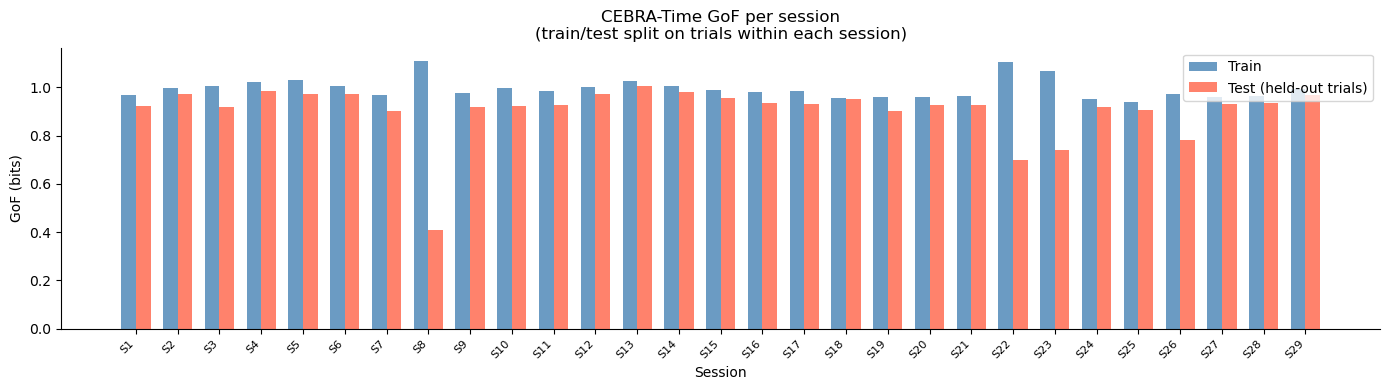

In [8]:
# ── Time-contrastive GoF bar chart ───────────────────────────────────────────
gof_time_train = np.load(os.path.join(output_dir, "gof_time_train.npy"))
gof_time_test  = np.load(os.path.join(output_dir, "gof_time_test.npy"))

x      = np.arange(num_sessions)
width  = 0.35
labels = [f"S{i+1}" for i in range(num_sessions)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - width/2, gof_time_train, width, label="Train",     color="steelblue",  alpha=0.8)
ax.bar(x + width/2, gof_time_test,  width, label="Test (held-out trials)", color="tomato", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Session")
ax.set_ylabel("GoF (bits)")
ax.set_title("CEBRA-Time GoF per session\n(train/test split on trials within each session)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# # ── Visualise embedding for one session ─────────────────────────────────────
# # Change session_idx to explore other sessions
# session_idx = 0
# session_id  = session_ids[session_idx]

# session_data   = session_dataset_singles[session_id]["data"]
# session_labels = session_dataset_singles[session_id]["labels"]

# test_trial_ids  = [int(idx) for idx in test_indices_by_session[session_id]]
# all_trial_ids   = list(session_data.keys())
# train_trial_ids = [idx for idx in all_trial_ids if idx not in test_trial_ids]

# train_data   = np.concatenate([session_data[idx]   for idx in train_trial_ids], axis=0)
# train_labels = np.concatenate([session_labels[idx] for idx in train_trial_ids], axis=0)
# test_data    = np.concatenate([session_data[idx]   for idx in test_trial_ids],  axis=0)
# test_labels  = np.concatenate([session_labels[idx] for idx in test_trial_ids],  axis=0)

# model = CEBRA(conditional="time", **CEBRA_KWARGS)
# model.load(os.path.join(models_dir, f"time_session_{session_idx:02d}.pt"))

# train_embedding = model.transform(train_data)
# test_embedding  = model.transform(test_data)

# # colour by first ensemble / neuron
# label_col = 0

# fig = cebra.integrations.plotly.plot_embedding_interactive(
#     train_embedding,
#     embedding_labels=train_labels[:, label_col],
#     title=f"CEBRA-Time train — {session_id}",
#     markersize=3,
#     cmap="rainbow",
# )
# fig.show()

# fig2 = cebra.integrations.plotly.plot_embedding_interactive(
#     test_embedding,
#     embedding_labels=test_labels[:, label_col],
#     title=f"CEBRA-Time test — {session_id}",
#     markersize=3,
#     cmap="rainbow",
# )
# fig2.show()

# ax = cebra.plot_loss(model)
# plt.title(f"Loss curve — {session_id}")
# plt.show()

## Behavior-contrastive CEBRA (supervised)

One model per session × neuron/ensemble. Labels are z-scored spike counts / ensemble projections.  
Train on 80% of trials, evaluate GoF on held-out 20%.

In [19]:
results_base = "./outputs/lstm/"

# ── LOOP 2: Train behavior-contrastive CEBRA per session × neuron ────────────
# Only train for (session, neuron) pairs where MLP R² > 0.1
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Load MLP R² matrix (shape: num_sessions × num_neurons)
if USE_ENSEMBLES:
    r2_mlp = np.load(os.path.join("./outputs/mlps/ensembles", "r2_matrix_mlp.npy"))
else:
    r2_mlp = np.load(os.path.join(results_base, "r2_matrix.npy"))

R2_THRESHOLD = 0.1
neurons_above = (r2_mlp > R2_THRESHOLD).sum()
print(f"Session×neuron pairs with MLP R² > {R2_THRESHOLD}: {neurons_above} / {num_sessions * num_neurons}")

try:
    gof_beh_train = np.load(os.path.join(output_dir, "gof_beh_train.npy"))
    gof_beh_test  = np.load(os.path.join(output_dir, "gof_beh_test.npy"))
    gof_beh_test_train_labels_shuffled = np.load(os.path.join(output_dir, "gof_beh_test_train_labels_shuffled.npy"))
    print("Loaded existing behavior-contrastive GoF results.")
except Exception:
    gof_beh_train = np.full((num_sessions, num_neurons), np.nan)
    gof_beh_test  = np.full((num_sessions, num_neurons), np.nan)
    gof_beh_test_train_labels_shuffled = np.full((num_sessions, num_neurons), np.nan)

beh_models_dir = os.path.join(models_dir, "behavior")
os.makedirs(beh_models_dir, exist_ok=True)

for sess_idx, session_id in enumerate(session_ids):
    session_data   = session_dataset_singles[session_id]["data"]
    session_labels = session_dataset_singles[session_id]["labels"]

    test_trial_ids  = [int(idx) for idx in test_indices_by_session[session_id]]
    all_trial_ids   = list(session_data.keys())
    train_trial_ids = [idx for idx in all_trial_ids if idx not in test_trial_ids]

    train_data   = np.concatenate([session_data[idx]   for idx in train_trial_ids], axis=0)
    train_labels = np.concatenate([session_labels[idx] for idx in train_trial_ids], axis=0)
    test_data    = np.concatenate([session_data[idx]   for idx in test_trial_ids],  axis=0)
    test_labels  = np.concatenate([session_labels[idx] for idx in test_trial_ids],  axis=0)

    neurons_this_session = (r2_mlp[sess_idx] > R2_THRESHOLD).sum()
    print(f"[{sess_idx+1}/{num_sessions}] {session_id}  "
          f"train={train_data.shape[0]}  test={test_data.shape[0]}  "
          f"neurons with R²>{R2_THRESHOLD}: {neurons_this_session}/{num_neurons}")

    for neuron_idx in range(num_neurons):
        if r2_mlp[sess_idx, neuron_idx] <= R2_THRESHOLD or not np.isnan(gof_beh_test[sess_idx, neuron_idx]):
            continue

        train_y = train_labels[:, neuron_idx]
        test_y  = test_labels[:, neuron_idx]

        model = CEBRA(
            conditional="time_delta",
            temperature=1.0,
            **{k: v for k, v in CEBRA_KWARGS.items() if k != "temperature"},
        )
        model.fit(train_data, train_y)

        gof_train = cebra.sklearn.metrics.goodness_of_fit_score(model, train_data, train_y)
        gof_test  = cebra.sklearn.metrics.goodness_of_fit_score(model, test_data,  test_y)

        gof_beh_train[sess_idx, neuron_idx] = gof_train
        gof_beh_test[sess_idx,  neuron_idx] = gof_test

        model_path = os.path.join(
            beh_models_dir, f"session_{sess_idx:02d}_neuron_{neuron_idx:02d}.pt")
        model.save(model_path)

        model_shuffled = CEBRA(
            conditional="time_delta",
            temperature=1.0,
            **{k: v for k, v in CEBRA_KWARGS.items() if k != "temperature"},
        )
        shuffled_train_y = np.random.permutation(train_y)
        model_shuffled.fit(train_data, shuffled_train_y)
        gof_shuffled = cebra.sklearn.metrics.goodness_of_fit_score(
            model_shuffled, test_data, test_y)
        gof_beh_test_train_labels_shuffled[sess_idx, neuron_idx] = gof_shuffled

        print(f"  neuron {neuron_idx+1}/{num_neurons}  "
              f"GoF train={gof_train:.4f}  GoF test={gof_test:.4f}  GoF shuffled={gof_shuffled:.4f}")



Session×neuron pairs with MLP R² > 0.1: 85 / 2233
Loaded existing behavior-contrastive GoF results.
[1/29] 2024-11-14_16-40  train=17835  test=5075  neurons with R²>0.1: 2/77
[2/29] 2024-11-15_15-48  train=33498  test=8349  neurons with R²>0.1: 1/77
[3/29] 2024-11-20_17-46  train=21332  test=4615  neurons with R²>0.1: 0/77
[4/29] 2024-11-21_17-22  train=24156  test=5604  neurons with R²>0.1: 0/77
[5/29] 2024-11-25_16-25  train=15395  test=4009  neurons with R²>0.1: 0/77
[6/29] 2024-11-26_16-39  train=23576  test=5659  neurons with R²>0.1: 2/77
[7/29] 2024-11-28_17-41  train=27785  test=6933  neurons with R²>0.1: 3/77
[8/29] 2024-11-29_17-21  train=1950  test=619  neurons with R²>0.1: 0/77
[9/29] 2024-12-02_16-09  train=25384  test=5367  neurons with R²>0.1: 2/77
[10/29] 2024-12-03_16-23  train=27330  test=6229  neurons with R²>0.1: 3/77
[11/29] 2024-12-04_18-06  train=25270  test=5404  neurons with R²>0.1: 4/77
[12/29] 2024-12-06_16-49  train=22990  test=5491  neurons with R²>0.1: 5/77

KeyboardInterrupt: 

In [18]:
np.save(os.path.join(output_dir, "gof_beh_train.npy"), gof_beh_train)
np.save(os.path.join(output_dir, "gof_beh_test.npy"),  gof_beh_test)
np.save(os.path.join(output_dir, "gof_beh_test_train_labels_shuffled.npy"), gof_beh_test_train_labels_shuffled)
print("\nBehavior-contrastive training complete.")


Behavior-contrastive training complete.


In [ ]:
# ── Reload saved GoF matrices ────────────────────────────────────────────────
gof_beh_train = np.load(os.path.join(output_dir, "gof_beh_train.npy"))
gof_beh_test  = np.load(os.path.join(output_dir, "gof_beh_test.npy"))

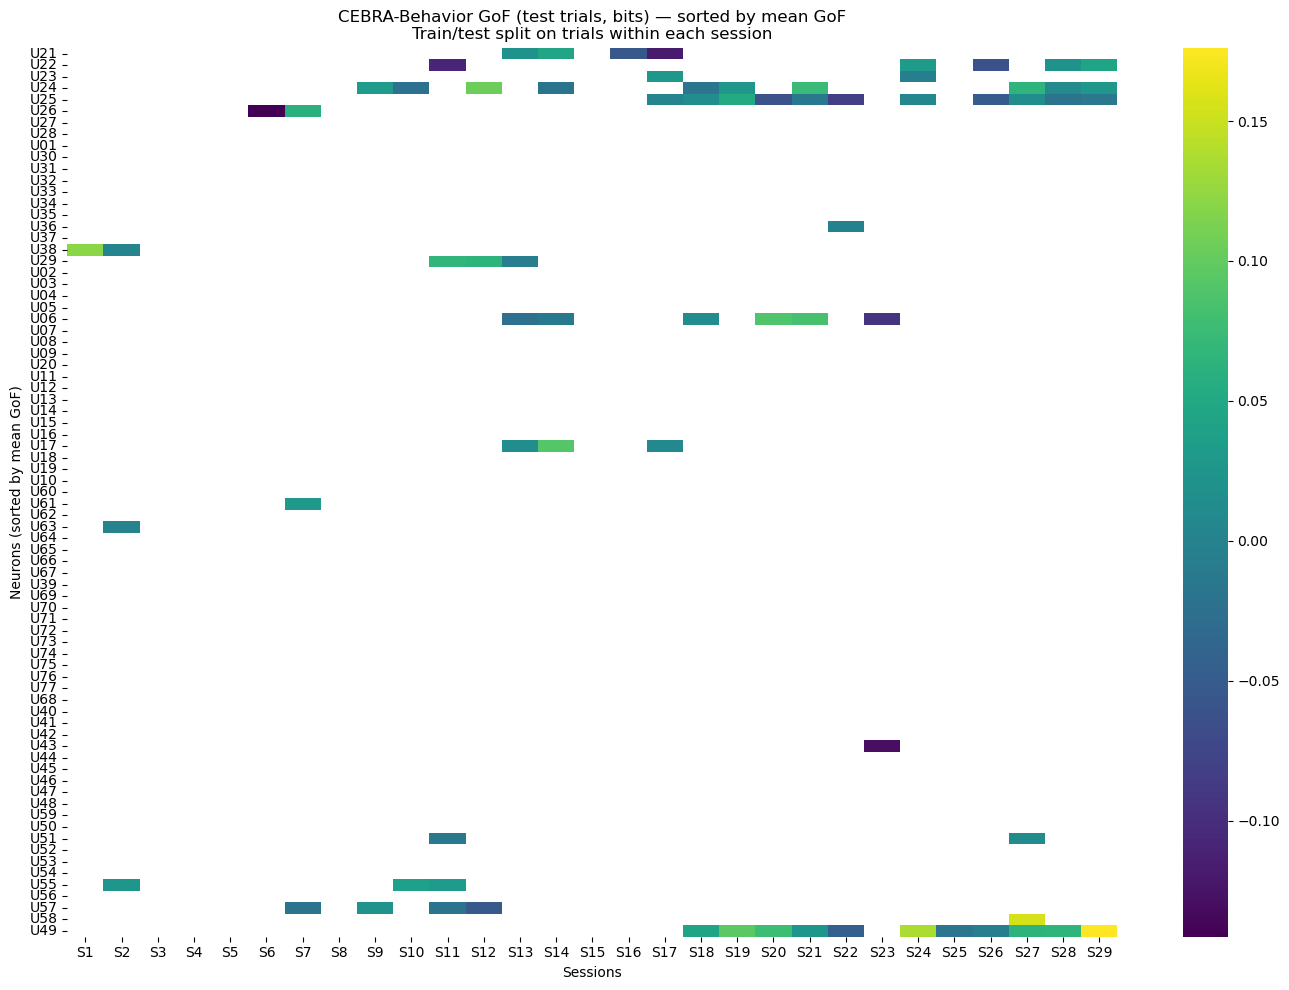

In [ ]:
# ── GoF heatmap (test) ────────────────────────────────────────────────────────
prefix_name  = "E" if USE_ENSEMBLES else "U"
neuron_mean  = gof_beh_test.mean(axis=0)
neuron_order = np.argsort(neuron_mean)[::-1]

gof_sorted = gof_beh_test[:, neuron_order].T

plt.figure(figsize=(14, 10))
sns.heatmap(
    gof_sorted,
    cmap="viridis",
    cbar=True,
    xticklabels=[f"S{i+1}" for i in range(num_sessions)],
    yticklabels=[f"{prefix_name}{neuron_order[i]+1:02d}" for i in range(num_neurons)],
)
label_str = "Ensembles" if USE_ENSEMBLES else "Neurons"
plt.title(f"CEBRA-Behavior GoF (test trials, bits) — sorted by mean GoF\n"
          f"Train/test split on trials within each session")
plt.ylabel(f"{label_str} (sorted by mean GoF)")
plt.xlabel("Sessions")
plt.tight_layout()
plt.show()

/tmp/ipykernel_12640/4086146983.py:36: RuntimeWarning: Mean of empty slice
  f"grand mean GoF = {np.nanmean(neuron_mean_test):.3f} bits",


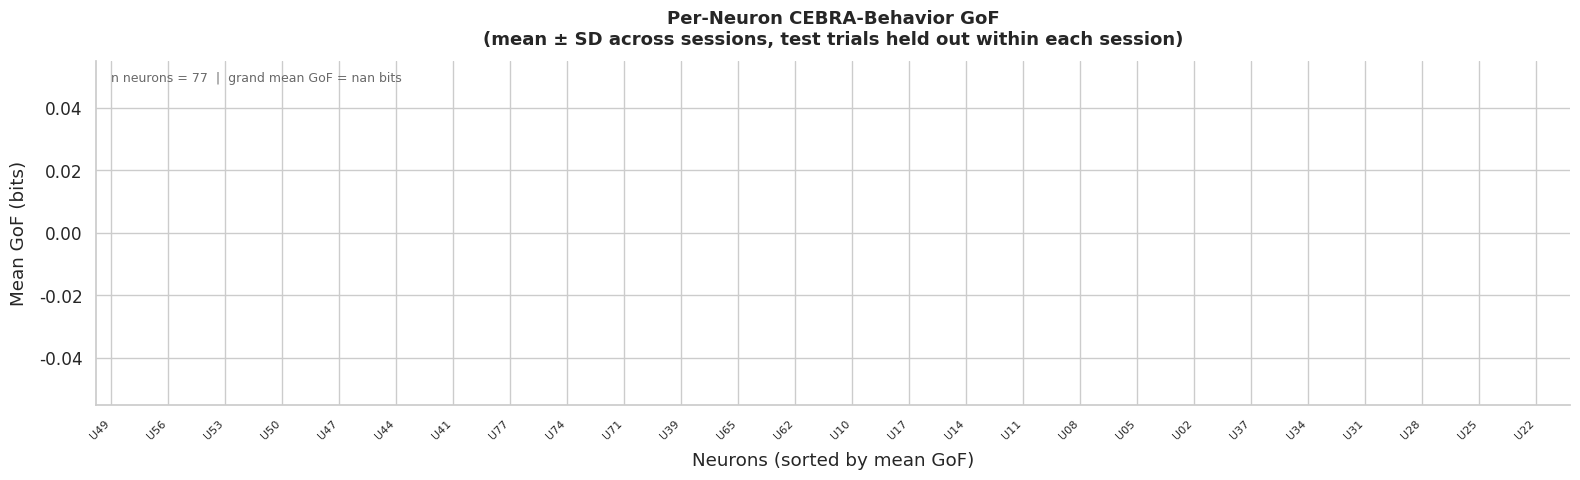

In [13]:
# ── Per-neuron GoF bar chart ──────────────────────────────────────────────────
neuron_mean_test = gof_beh_test.mean(axis=0)
neuron_std_test  = gof_beh_test.std(axis=0)

order   = np.argsort(neuron_mean_test)
x       = np.arange(num_neurons)
labels  = [f"{prefix_name}{i+1:02d}" for i in order]
means_s = neuron_mean_test[order]
stds_s  = neuron_std_test[order]

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
palette = sns.color_palette("mako_r", as_cmap=True)
colors  = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.errorbar(x, means_s, yerr=stds_s,
            fmt="none", ecolor="gray", elinewidth=0.8,
            capsize=3, capthick=0.8, zorder=4, alpha=0.7)

ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right", fontsize=8)
ax.set_xlabel(f"{label_str} (sorted by mean GoF)", labelpad=8)
ax.set_ylabel("Mean GoF (bits)", labelpad=8)
ax.set_title(
    f"Per-{'Ensemble' if USE_ENSEMBLES else 'Neuron'} CEBRA-Behavior GoF\n"
    f"(mean ± SD across sessions, test trials held out within each session)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.spines[["top", "right"]].set_visible(False)

ax.annotate(
    f"n {label_str.lower()} = {num_neurons}  |  "
    f"grand mean GoF = {np.nanmean(neuron_mean_test):.3f} bits",
    xy=(0.01, 0.97), xycoords="axes fraction",
    va="top", ha="left", fontsize=9, color="dimgray",
)
plt.tight_layout()
plt.show()

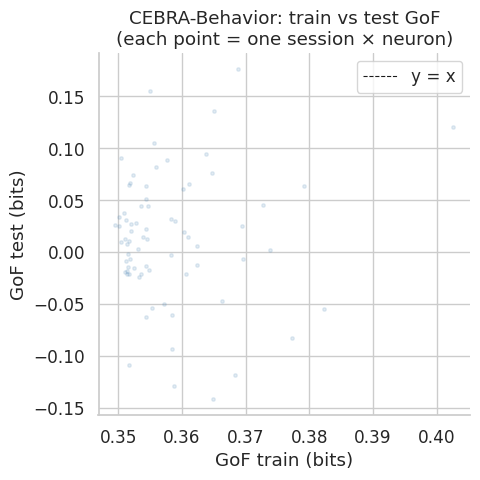

In [14]:
# ── Train vs test GoF scatter (overfitting check) ────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gof_beh_train.ravel(), gof_beh_test.ravel(),
           alpha=0.15, s=6, color="steelblue")
lims = [
    min(gof_beh_train.min(), gof_beh_test.min()),
    max(gof_beh_train.max(), gof_beh_test.max()),
]
ax.plot(lims, lims, "k--", linewidth=0.8, label="y = x")
ax.set_xlabel("GoF train (bits)")
ax.set_ylabel("GoF test (bits)")
ax.set_title("CEBRA-Behavior: train vs test GoF\n(each point = one session × neuron)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()